In [2]:
#coding: UTF-8
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import h5py
import csv
import math
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.animation as animation
from matplotlib.animation import ArtistAnimation

dir1 = '/Users/maedarn/Dropbox/analysis/low_metal/lmt_m0-2-v100-tp/'

/var/folders/kw/hmy8d3gn14j8321d_1qs3ry40000gn/T/ipykernel_69946/2648235847.py:43: RuntimeWarning: divide by zero encountered in log10
  xfgr2Dn= np.log10(nfgr3Dt[64,:,:]*1.27/Rho3Dt[64,:,:] *SH)


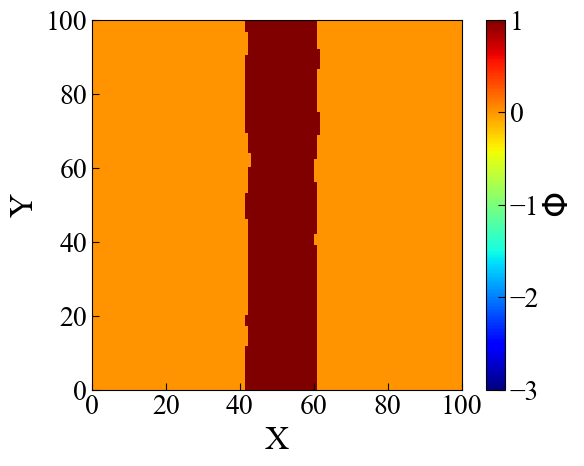

In [3]:
i = 30
nmesh=128.0
with h5py.File(dir1+'zHDFALL'+"%03.f"%(i)+'.h5',"r") as f:
    Rho= f["RHO/RHO"]
    P  = f["P/P"]
    Vx = f["V/VX"]
    Vy = f["V/VY"]
    Vz = f["V/VZ"]
    Bx = f["B/BX"]
    By = f["B/BY"]
    Bz = f["B/BZ"]
    nfgr = f["RHO-fgr/RHO-fgr"]



    Rho3D= Rho[()]
    Rho3Dt=Rho3D.transpose(2, 1, 0)
    Rho2D= np.log10(Rho3Dt[64,:,:])

    P3D= P[()]
    P3Dt=P3D.transpose(2, 1, 0)
    P2D= np.log10(P3Dt[64,:,:])

    By3D= By[()]
    By3Dt=By3D.transpose(2, 1, 0)
    By2D= By3Dt[64,:,:]

    Vx3D= Vx[()]
    Vx3Dt=Vx3D.transpose(2, 1, 0)
    Vx2D= Vx3Dt[64,:,:]

    nfgr3D= nfgr[()]
    nfgr3Dt=nfgr3D.transpose(2, 1, 0)
    nfgr2D= np.log10(nfgr3Dt[64,:,:])
    xfgr2D= np.log10(nfgr3Dt[64,:,:]*1.27/Rho3Dt[64,:,:])

    Rhosh = np.where(Rho2D >= 4.0, 1, 0)
    Vxsh  = np.where(abs(Vx2D) <= 40.0, 1, 0)
    
    SH = Rhosh + Vxsh
    SH = np.where(SH >= 1, 1, 0)

    xfgr2Dn= np.log10(nfgr3Dt[64,:,:]*1.27/Rho3Dt[64,:,:] *SH)



    

fig = plt.figure()
ax = fig.add_subplot(111)
#fig.subplots_adjust(bottom=0, left=0, top=1, right=1)

plt.rcParams["font.family"] = "Times New Roman"      #全体のフォントを設定
plt.rcParams["xtick.direction"] = "in"               #x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams["ytick.direction"] = "in"               #y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams["xtick.major.size"] = 5                #x軸主目盛り線の長さ
plt.rcParams["ytick.major.size"] = 5                #y軸主目盛り線の長さ
plt.rcParams["font.size"] = 20                       #フォントの大きさ


x = np.arange(0.0, 100.1, 100.0/nmesh)
y = np.arange(0.0, 100.1, 100.0/nmesh)
plt.pcolormesh(x,y,SH, cmap='jet') # 等高線図の生成。cmapで色付けの規則を指定する。


#plt.contour(x,y, SH,colors='black')    #等高線表示
#ax.clabel(fmt='%1.1f', fontsize=16)        

plt.clim(-3.0, 1.0)
pp=plt.colorbar (orientation="vertical") # カラーバーの表示 "vertical"
pp.set_label("$\Phi$", fontsize=24) #カラーバーのラベル
plt.xlim([-0.0, 100.0]) # x方向の描画範囲を指定
plt.ylim([-0.0, 100.0]) # y方向の描画範囲を指定
plt.xlabel('X', fontsize=24)
plt.ylabel('Y', fontsize=24)
plt.xticks(np.arange(0, 101, step=20))
plt.yticks(np.arange(0, 101, step=20))
#fig = plt.figure(figsize=(5, 5))
#ax.set_aspect('equal', adjustable='box')
#quadmesh.set_clim(vmin=0, vmax=15)
#plt.axes().set_aspect('equal', 'datalim')
plt.gca().set_aspect('equal')



#pp = PdfPages('/Users/maeda/Desktop/phi'+"%03.f"%(i)+'.pdf')
pp = PdfPages('/Users/maedarn/Desktop/phierr.pdf')
# 画像をPDFとして保存する
pp.savefig(fig, bbox_inches='tight')
# PDFの保存終了
pp.close()


plt.show()

In [45]:
import cv2
 
# 画像を読み込みリサイズ後にグレースケール化
#img = cv2.imread(SH, 1)
#img = cv2.resize(img, (w, h))
#img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 二値化
#ret, img_binary = cv2.threshold(img_gray, 100, 255, cv2.THRESH_BINARY_INV)

# 輪郭抽出
contours, hierarchy = cv2.findContours(img_binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
img_plot(img_binary)
 
# 位置座標化
x_boundary = []
y_boundary = []
for i in range(len(contours)):
    for j in range(len(contours[i])):
        x = contours[i][j][0][0]
        y = contours[i][j][0][1]
        x_boundary.append(x)
        y_boundary.append(np.abs(y))

error: OpenCV(4.10.0) :-1: error: (-5:Bad argument) in function 'imread'
> Overload resolution failed:
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object


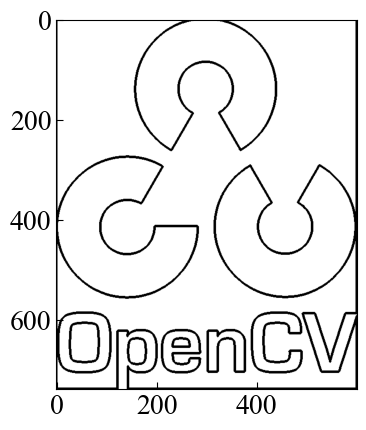

In [48]:
#解説1
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

#解説2
# サンプル画像のURL
url = 'https://upload.wikimedia.org/wikipedia/commons/5/53/OpenCV_Logo_with_text.png'
# 画像読み込む
img = io.imread(url)

#解説3
# グレースケールに変換
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# 二値化（閾値を150に設定）
ret, binary = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

#解説4
# 輪郭を検出
contours, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

#解説5
# 全て白の画像を作成
img_blank = np.ones_like(img) * 255
# 輪郭だけを描画（黒色で描画）
img_contour_only = cv2.drawContours(img_blank, contours, -1, (0,0,0), 3)
# 描画
plt.imshow(cv2.cvtColor(img_contour_only, cv2.COLOR_BGR2RGB))
plt.show()

/var/folders/kw/hmy8d3gn14j8321d_1qs3ry40000gn/T/ipykernel_2330/874902866.py:48: RuntimeWarning: divide by zero encountered in log10
  xfgr2Dn= np.log10(nfgr3Dt[64,:,:]*1.27/Rho3Dt[64,:,:] *SH)


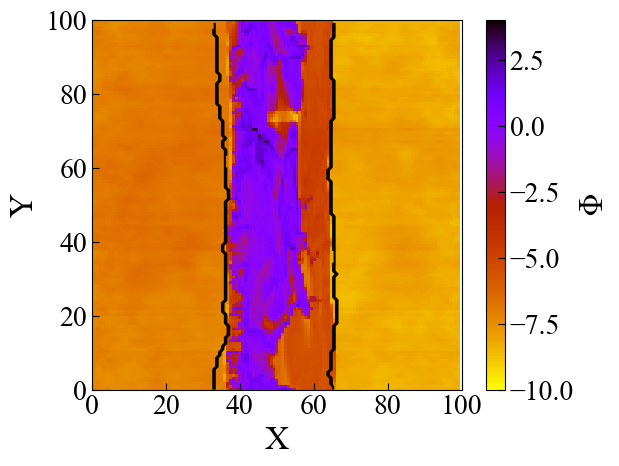

In [40]:
i = 50
nmesh=128.0
with h5py.File(dir1+'zHDFALL'+"%03.f"%(i)+'.h5',"r") as f:
    Rho= f["RHO/RHO"]
    P  = f["P/P"]
    Vx = f["V/VX"]
    Vy = f["V/VY"]
    Vz = f["V/VZ"]
    Bx = f["B/BX"]
    By = f["B/BY"]
    Bz = f["B/BZ"]
    nfgr = f["RHO-fgr/RHO-fgr"]
    nH2 = f["RHO-h2/RHO-h2"]



    Rho3D= Rho[()]
    Rho3Dt=Rho3D.transpose(2, 1, 0)
    Rho2D= np.log10(Rho3Dt[:,64,:])

    P3D= P[()]
    P3Dt=P3D.transpose(2, 1, 0)
    P2D= np.log10(P3Dt[64,:,:])

    By3D= By[()]
    By3Dt=By3D.transpose(2, 1, 0)
    By2D= By3Dt[64,:,:]

    Vx3D= Vx[()]
    Vx3Dt=Vx3D.transpose(2, 1, 0)
    Vx2D= Vx3Dt[:,64,:]

    nfgr3D= nfgr[()]
    nfgr3Dt=nfgr3D.transpose(2, 1, 0)
    nfgr2D= np.log10(nfgr3Dt[:,64,:])
    xfgr2D= np.log10(nfgr3Dt[:,64,:]*1.27/Rho3Dt[:,64,:])

    nH23D= nH2[()]
    nH23Dt=nH23D.transpose(2, 1, 0)
    nH22D= np.log10(nH23Dt[64,:,:])

    Rhosh = np.where(Rho2D >= 4.0, 1, 0)
    Vxsh  = np.where(abs(Vx2D) <= 40.0, 1, 0)
    
    SH = Rhosh + Vxsh
    SH = np.where(SH >= 1, 1, 0)

    xfgr2Dn= np.log10(nfgr3Dt[64,:,:]*1.27/Rho3Dt[64,:,:] *SH)



    

fig = plt.figure()
ax = fig.add_subplot(111)
#fig.subplots_adjust(bottom=0, left=0, top=1, right=1)

plt.rcParams["font.family"] = "Times New Roman"      #全体のフォントを設定
plt.rcParams["xtick.direction"] = "in"               #x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams["ytick.direction"] = "in"               #y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams["xtick.major.size"] = 5                #x軸主目盛り線の長さ
plt.rcParams["ytick.major.size"] = 5                #y軸主目盛り線の長さ
plt.rcParams["font.size"] = 20                       #フォントの大きさ


x = np.arange(0.0, 100., 100.0/nmesh)
y = np.arange(0.0, 100., 100.0/nmesh)

X, Y = np.meshgrid(x, y)
#Z = np.sin(X) + np.cos(Y)   # 表示する計算式の指定。等高線はZに対して作られる。

# 等高線図の生成。
cont=plt.contour(X,Y,SH,  1, vmin=-1,vmax=1, colors=['black'])
cont.clabel(fmt='%1.1f', fontsize=0)


plt.xlabel('X', fontsize=24)
plt.ylabel('Y', fontsize=24)

#plt.pcolormesh(X,Y,nH22D, cmap='jet') #カラー等高線図
plt.pcolormesh(X,Y,nH22D, cmap='gnuplot_r')
#plt.clim(-3.0, 1.0)
plt.clim(-10.0, 4.0)
pp=plt.colorbar (orientation="vertical") # カラーバーの表示 "vertical"
pp.set_label("$\Phi$", fontsize=24) #カラーバーのラベル
plt.xlim([-0.0, 100.0]) # x方向の描画範囲を指定
plt.ylim([-0.0, 100.0]) # y方向の描画範囲を指定
plt.xlabel('X', fontsize=24)
plt.ylabel('Y', fontsize=24)
plt.xticks(np.arange(0, 101, step=20))
plt.yticks(np.arange(0, 101, step=20))
#fig = plt.figure(figsize=(5, 5))
#ax.set_aspect('equal', adjustable='box')
#quadmesh.set_clim(vmin=0, vmax=15)
#plt.axes().set_aspect('equal', 'datalim')
plt.gca().set_aspect('equal')



#pp = PdfPages('/Users/maeda/Desktop/phi'+"%03.f"%(i)+'.pdf')
pp = PdfPages('/Users/maedarn/Desktop/xfgr_yx.pdf')
# 画像をPDFとして保存する
pp.savefig(fig, bbox_inches='tight')
# PDFの保存終了
pp.close()



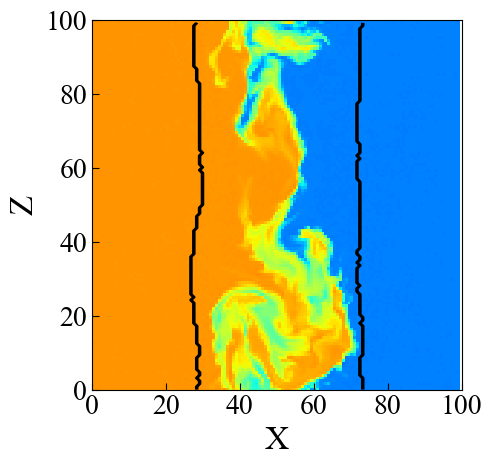

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig = plt.figure()


plt.rcParams["font.family"] = "Times New Roman"      #全体のフォントを設定
plt.rcParams["xtick.direction"] = "in"               #x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams["ytick.direction"] = "in"               #y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams["xtick.major.size"] = 5                #x軸主目盛り線の長さ
plt.rcParams["ytick.major.size"] = 5                #y軸主目盛り線の長さ
plt.rcParams["font.size"] = 20   

x = np.arange(0.0, 100., 100.0/nmesh)
y = np.arange(0.0, 100., 100.0/nmesh)
X, Y = np.meshgrid(x, y)
ims = []

for i in range(1,96):
    with h5py.File(dir1+'zHDFALL'+"%03.f"%(i)+'.h5',"r") as f:
        Rho= f["RHO/RHO"]
        P  = f["P/P"]
        Vx = f["V/VX"]
        Vy = f["V/VY"]
        Vz = f["V/VZ"]
        nfgr = f["RHO-fgr/RHO-fgr"]
        nH2 = f["RHO-h2/RHO-h2"]

        Rho3D= Rho[()]
        Rho3Dt=Rho3D.transpose(2, 1, 0)
        Rho2D= np.log10(Rho3Dt[:,64,:])
        #Rho2D= np.log10(Rho3Dt[64,:,:])

        Vx3D= Vx[()]
        Vx3Dt=Vx3D.transpose(2, 1, 0)
        Vx2D= Vx3Dt[:,64,:]
        #Vx2D= Vx3Dt[64,:,:]

        nfgr3D= nfgr[()]
        nfgr3Dt=nfgr3D.transpose(2, 1, 0)
        xfgr2D= np.log10(nfgr3Dt[:,64,:]*1.27/Rho3Dt[:,64,:])
        #xfgr2D= np.log10(nfgr3Dt[64,:,:]*1.27/Rho3Dt[64,:,:])

        nH23D= nH2[()]
        nH23Dt=nH23D.transpose(2, 1, 0)
        #Rho2D= np.log10(Rho3Dt[:,64,:])
        nH22D= np.log10(nH23Dt[:,64,:])
        #nH22D= np.log10(nH23Dt[64,:,:])

        Rhosh = np.where(Rho2D >= 4.0, 1, 0)
        Vxsh  = np.where(abs(Vx2D) <= 40.0, 1, 0)
        
        SH = Rhosh + Vxsh
        SH = np.where(SH >= 1, 1, 0)
        
        #im =  plt.pcolormesh(X,Y,xfgr2D, cmap='gnuplot_r')
        im =  plt.pcolormesh(X,Y,xfgr2D, cmap='jet')
        plt.clim(-3.0, 1.0)
        plt.xlim([-0.0, 100.0]) # x方向の描画範囲を指定
        plt.ylim([-0.0, 100.0]) # y方向の描画範囲を指定
        plt.xlabel('X', fontsize=24)
        plt.ylabel('Z', fontsize=24)
        plt.xticks(np.arange(0, 101, step=20))
        plt.yticks(np.arange(0, 101, step=20))
        plt.gca().set_aspect('equal')

        jm = plt.contour(X,Y,SH,  1, vmin=-1,vmax=1, colors=['black'])

        ims.append([im]+[jm])

ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True,repeat_delay=1000)

#ani.save('/Users/maedarn/Desktop/anim.gif', writer="imagemagick")
ani.save('/Users/maedarn/Desktop/frg_xz_l.mp4', writer="ffmpeg")
plt.show()

[-0. -0. -0. ... -0. -0. -0.]
3.840346 1.0 3.840346097946167 0.003545379266142845 0.057811406


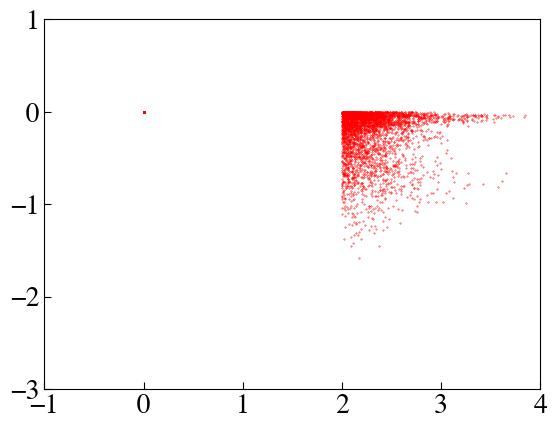

In [26]:
i = 50
nmesh=128.0
with h5py.File(dir1+'zHDFALL'+"%03.f"%(i)+'.h5',"r") as f:
    Rho= f["RHO/RHO"]
    P  = f["P/P"]
    Vx = f["V/VX"]
    Vy = f["V/VY"]
    Vz = f["V/VZ"]
    Bx = f["B/BX"]
    By = f["B/BY"]
    Bz = f["B/BZ"]
    nfgr = f["RHO-fgr/RHO-fgr"]
    nH2 = f["RHO-h2/RHO-h2"]

    Rho3D= Rho[()]
    Rho3Dt=Rho3D.transpose(2, 1, 0)

    nH23D= nH2[()]
    nH23Dt=np.log10(nH23D.transpose(2, 1, 0))

    nfgr3D= nfgr[()]
    nfgr3Dt=nfgr3D.transpose(2, 1, 0)
    xfgr3D= np.log10(nfgr3Dt[:,:,:]*1.27/Rho3Dt[:,:,:])


    #xfgr2Dn= np.log10(nfgr3Dt[64,:,:]*1.27/Rho3Dt[64,:,:] *SH)

    nfrg1D=xfgr3D.flatten()
    nH21D =nH23Dt.flatten()
    nH21Dden =np.where(nH21D > 2.0, 1.0 ,0.0)
    HDnH21D = nH21D * nH21Dden 
    HDnfrg1D = nfrg1D * nH21Dden 


print(HDnH21D)
print(np.max(nH21D),np.max(nH21Dden),np.max(HDnH21D),np.max(HDnfrg1D),np.max(nfrg1D))



fig = plt.figure()
ax = fig.add_subplot(111)
#fig.subplots_adjust(bottom=0, left=0, top=1, right=1)

#Vx_sh=Vx * shocked_Region 
#x = np.arange(1, 6)

plt.scatter(HDnH21D, HDnfrg1D, s=0.1,color='red')
ax.set_xlim([-1, 4])
ax.set_ylim([-3,  1])

pp = PdfPages('/Users/maedarn/Desktop/n_H2_xfrg.pdf')
pp.savefig(fig, bbox_inches='tight')
pp.close()



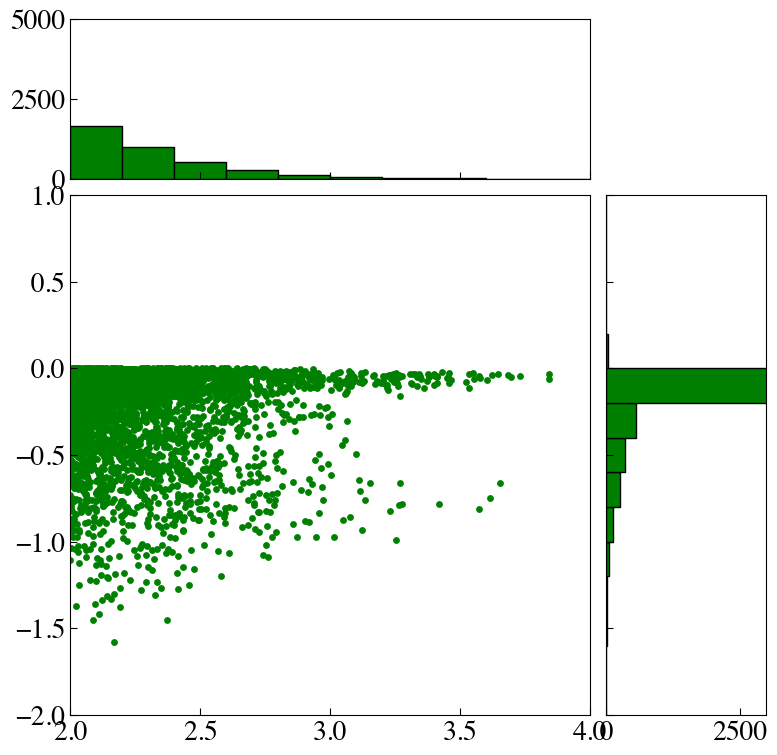

In [29]:
#グラフプロットの定義###
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    ax_histx.tick_params(axis="x", labelbottom=False) #x軸ラベル無し
    ax_histy.tick_params(axis="y", labelleft=False) #y軸ラベル無し
    ax.scatter(x, y, color='green', marker='o', s=15.2) #散布図のプロット
    
    xbinwidth = 0.2 #bin(ビン)は、ヒストグラムにおいてバー1本の事。ここでbinの値幅を定義。
    ybinwidth = 0.2
    #xymax = max(np.max(np.abs(x)), np.max(np.abs(y))) #xとyの最大値を定義
    xmax = 7 #max(np.max(np.abs(x)), np.max(np.abs(y))) 
    ymax = 7 #max(np.max(np.abs(x)), np.max(np.abs(y))) 
    
    lim1=(int(xmax/xbinwidth) + 1) * xbinwidth
    lim2=(int(ymax/ybinwidth) + 1) * ybinwidth
    #lim = (int(xymax/binwidth) + 1) * binwidth #ヒストグラムの横軸を定義
    

    #bins = np.arange(-lim, lim + binwidth, binwidth) #binの個数を定義
    bins1 = np.arange(-lim1, lim1 + xbinwidth, xbinwidth) #binの個数を定義
    bins2 = np.arange(-lim2, lim2 + ybinwidth, ybinwidth) #binの個数を定義
    ax_histx.hist(x, bins=bins1, color='green', ec='black') #xについてのヒストグラム作成
    ax_histy.hist(y, bins=bins2, orientation='horizontal', color='green', ec='black') #yについてのヒストグラム作成
    ax_histx.set_ylim([0, 5000])
    ax_histy.set_xlim([0, 3000])
    plt.tick_params(labelsize = 20)
    #################


x = HDnH21D
y = HDnfrg1D

left, width = 0.1, 0.65 #散布図の左余白と、幅を定義
bottom, height = 0.1, 0.65 #散布図の下余白と、高さを定義
spacing = 0.02 #散布図とヒストグラムの間隔

fig_scatter = [left, bottom, width, height] #散布図の定義
fig_histx = [left, bottom + height + spacing, width, 0.2] #上のヒストグラムの定義
fig_histy = [left + width + spacing, bottom, 0.2, height] #右のヒストグラムの定義

fig = plt.figure(figsize=(8, 8)) #描写領域を正方形で生成

ax = fig.add_axes(fig_scatter) #図1として散布図領域を生成
ax_histx = fig.add_axes(fig_histx, sharex=ax) #上のヒストグラム領域を生成
ax_histy = fig.add_axes(fig_histy, sharey=ax) #右のヒストグラム領域を生成

ax.set_xlim([2, 4])
ax.set_ylim([-2, 1])

#最後にscatter_histでまとめて描写
scatter_hist(x, y, ax, ax_histx, ax_histy)

plt.rcParams["font.family"] = "Times"      #全体のフォントを設定
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['mathtext.default'] = 'it'
plt.rcParams["xtick.direction"] = "in"               #x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams["ytick.direction"] = "in"               #y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
#plt.rcParams["xtick.minor.visible"] = True          #x軸補助目盛りの追加
#plt.rcParams["ytick.minor.visible"] = True          #y軸補助目盛りの追加
#plt.rcParams["xtick.major.width"] = 1.5              #x軸主目盛り線の線幅
#plt.rcParams["ytick.major.width"] = 1.5              #y軸主目盛り線の線幅
#plt.rcParams["xtick.minor.width"] = 1.0              #x軸補助目盛り線の線幅
#plt.rcParams["ytick.minor.width"] = 1.0              #y軸補助目盛り線の線幅
plt.rcParams["xtick.major.size"] = 5                #x軸主目盛り線の長さ
plt.rcParams["ytick.major.size"] = 5                #y軸主目盛り線の長さ
#plt.rcParams["xtick.minor.size"] = 5                #x軸補助目盛り線の長さ
#plt.rcParams["ytick.minor.size"] = 5                #y軸補助目盛り線の長さ
plt.rcParams["font.size"] = 20                       #フォントの大きさ
#plt.rcParams["axes.linewidth"] = 1.5                 #囲みの太さ
#plt.xlim([-1.0, 2000.0]) # x方向の描画範囲を指定
#plt.ylim([0.001, 1.0]) # y方向の描画範囲を指定
plt.rcParams["legend.markerscale"] = 2
plt.rcParams["legend.fancybox"] = False
plt.rcParams["legend.framealpha"] = 1
plt.rcParams["legend.edgecolor"] = 'black'



plt.show()

pp = PdfPages('/Users/maedarn/Desktop/HISTplot.pdf')
# 画像をPDFとして保存する
pp.savefig(fig)
# PDFの保存終了
pp.close()


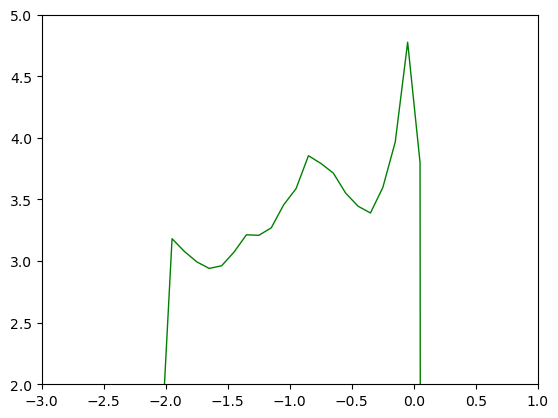

In [9]:
dir1 = '/Users/maedarn/Dropbox/analysis/low_metal/lmt_m0-2-v100-tp/'

data_file = 'MTL_HST096.DAT'
Zmtl = np.loadtxt(dir1+data_file, comments='#', usecols = 0)
Mtot = np.loadtxt(dir1+data_file, comments='#', usecols = 1)

plt.xlim([-3.0, 1.0]) # x方向の描画範囲を指定
plt.ylim([2.0, 5.0]) # y方向の描画範囲を指定

plt.plot(Zmtl,Mtot, color='green' , linestyle = "solid", markersize=2.5, linewidth = 1)